# **Medical Text Analysis for Disease and Drug Entities**

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import spacy
from spacy.tokens import DocBin
from tqdm import tqdm

In [ ]:
data = pd.read_json('Corona2.json')
data.head()

,examples
0,"{'id': '18c2f619-f102-452f-ab81-d26f7e283ffe',..."
1,"{'id': '487c93e3-0d45-4088-a378-cf3a01c8953d',..."
2,"{'id': 'd5056874-895a-4a7f-9e0f-828d414d65d9',..."
3,"{'id': '20c792c7-0c4b-42d0-8127-0e04113db384',..."
4,"{'id': 'f5359e0d-4d4a-4707-95a3-4c627fc4a83b',..."


In [ ]:
list(data['examples'][0].keys())

['id', 'content', 'metadata', 'annotations', 'classifications']

In [ ]:
data['examples'][0]['content']

"While bismuth compounds (Pepto-Bismol) decreased the number of bowel movements in those with travelers' diarrhea, they do not decrease the length of illness.[91] Anti-motility agents like loperamide are also effective at reducing the number of stools but not the duration of disease.[8] These agents should be used only if bloody diarrhea is not present.[92]\n\nDiosmectite, a natural aluminomagnesium silicate clay, is effective in alleviating symptoms of acute diarrhea in children,[93] and also has some effects in chronic functional diarrhea, radiation-induced diarrhea, and chemotherapy-induced diarrhea.[45] Another absorbent agent used for the treatment of mild diarrhea is kaopectate.\n\nRacecadotril an antisecretory medication may be used to treat diarrhea in children and adults.[86] It has better tolerability than loperamide, as it causes less constipation and flatulence.[94]"

In [ ]:
data['examples'][0]['annotations'][0]

{'id': '0825a1bf-6a6e-4fa2-be77-8d104701eaed',
 'tag_id': 'c06bd022-6ded-44a5-8d90-f17685bb85a1',
 'end': 371,
 'start': 360,
 'example_id': '18c2f619-f102-452f-ab81-d26f7e283ffe',
 'tag_name': 'Medicine',
 'value': 'Diosmectite',
 'correct': None,
 'human_annotations': [{'timestamp': '2020-03-21T00:24:32.098000Z',
   'annotator_id': 1,
   'tagged_token_id': '0825a1bf-6a6e-4fa2-be77-8d104701eaed',
   'name': 'Ashpat123',
   'reason': 'exploration'}],
 'model_annotations': []}

In [ ]:
training_data = [{'text': example['content'],
                  'entities': [(annotation['start'], annotation['end'], annotation['tag_name'].upper())
                               for annotation in example['annotations']]}
                 for example in data['examples']]

In [ ]:
training_data[0]['entities']

[(360, 371, 'MEDICINE'),
 (383, 408, 'MEDICINE'),
 (104, 112, 'MEDICALCONDITION'),
 (679, 689, 'MEDICINE'),
 (6, 23, 'MEDICINE'),
 (25, 37, 'MEDICINE'),
 (461, 470, 'MEDICALCONDITION'),
 (577, 589, 'MEDICINE'),
 (853, 865, 'MEDICALCONDITION'),
 (188, 198, 'MEDICINE'),
 (754, 762, 'MEDICALCONDITION'),
 (870, 880, 'MEDICALCONDITION'),
 (823, 833, 'MEDICINE'),
 (852, 853, 'MEDICALCONDITION'),
 (461, 469, 'MEDICALCONDITION'),
 (535, 543, 'MEDICALCONDITION'),
 (692, 704, 'MEDICINE'),
 (563, 571, 'MEDICALCONDITION')]

In [ ]:
training_data[0]['text'][544:571]

' radiation-induced diarrhea'

In [ ]:
nlp = spacy.blank("en")
doc_bin = DocBin()

In [ ]:
from spacy.util import filter_spans

for training_example in tqdm(training_data):
    text = training_example['text']
    labels = training_example['entities']
    doc = nlp.make_doc(text)
    ents = []
    for start, end, label in labels:
        span = doc.char_span(start, end, label=label, alignment_mode="contract")
        if span is None:
            print("Skipping entity")
        else:
            ents.append(span)
    filtered_ents = filter_spans(ents)
    doc.set_ents(filtered_ents)
    doc_bin.add(doc)

doc_bin.to_disk("train.spacy")

100%|██████████| 31/31 [00:00<00:00, 225.29it/s]

Skipping entity
Skipping entity
Skipping entity
Skipping entity
Skipping entity
Skipping entity
Skipping entity
Skipping entity
Skipping entity
Skipping entity
Skipping entity
Skipping entity
Skipping entity
Skipping entity
Skipping entity
Skipping entity


In [ ]:
! python -m spacy init config config.cfg --lang en --pipeline ner --optimize efficiency

⚠ To generate a more effective transformer-based config (GPU-only),
install the spacy-transformers package and re-run this command. The config
generated now does not use transformers.
ℹ Generated config template specific for your use case
- Language: en
- Pipeline: ner
- Optimize for: efficiency
- Hardware: CPU
- Transformer: None
✔ Auto-filled config with all values
✔ Saved config
config.cfg
You can now add your data and train your pipeline:
python -m spacy train config.cfg --paths.train ./train.spacy --paths.dev ./dev.spacy


In [ ]:
! python -m spacy train config.cfg --output ./ --paths.train ./train.spacy --paths.dev ./train.spacy

ℹ Saving to output directory: .
ℹ Using CPU

=========================== Initializing pipeline ===========================
✔ Initialized pipeline

============================= Training pipeline =============================
ℹ Pipeline: ['tok2vec', 'ner']
ℹ Initial learn rate: 0.001
E    #       LOSS TOK2VEC  LOSS NER  ENTS_F  ENTS_P  ENTS_R  SCORE 
---  ------  ------------  --------  ------  ------  ------  ------
  0       0          0.00    153.29    0.00    0.00    0.00    0.00
  7     200        734.85   3155.35   76.73   79.66   74.02    0.77
 14     400        669.55    734.48   97.24   97.24   97.24    0.97
 22     600        945.17    272.49   98.03   98.03   98.03    0.98
 30     800        188.78    219.05   98.23   98.04   98.43    0.98
 40    1000        224.41    192.51   98.41   99.20   97.64    0.98
 51    1200        206.75    185.68   98.24   97.67   98.82    0.98
 65    1400        142.57    143.77   98.43   98.43   98.43    0.98
 81    1600        132.46    167.75 

In [ ]:
nlp_trained_model = spacy.load("model-best")

In [ ]:
doc = nlp_trained_model('''
1. The patient was prescribed Lisinopril to manage high blood pressure and reduce the risk of heart attack.
2. Ibuprofen was recommended to alleviate the patient’s pain and inflammation following a dental procedure.
3. The patient is currently undergoing chemotherapy to treat lung cancer, which was diagnosed last year.
4. For her diabetes, the doctor suggested Metformin as part of the patient’s daily medication routine.
5. The patient exhibited symptoms of pneumonia and was immediately started on a course of Azithromycin.
''')

In [ ]:
spacy.displacy.render(doc, style="ent", jupyter=True)

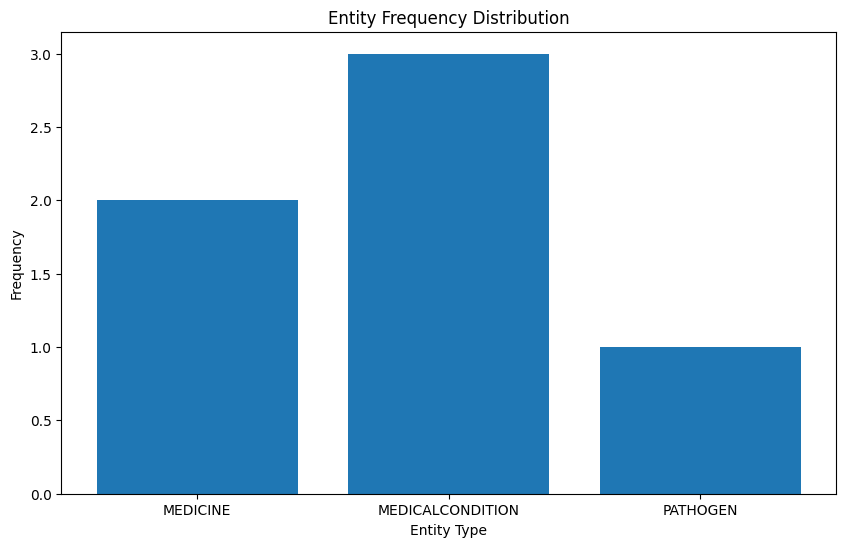

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

entity_labels = [ent.label_ for ent in doc.ents]
entity_counts = Counter(entity_labels)

plt.figure(figsize=(10, 6))
plt.bar(entity_counts.keys(), entity_counts.values())
plt.xlabel("Entity Type")
plt.ylabel("Frequency")
plt.title("Entity Frequency Distribution")
plt.show()

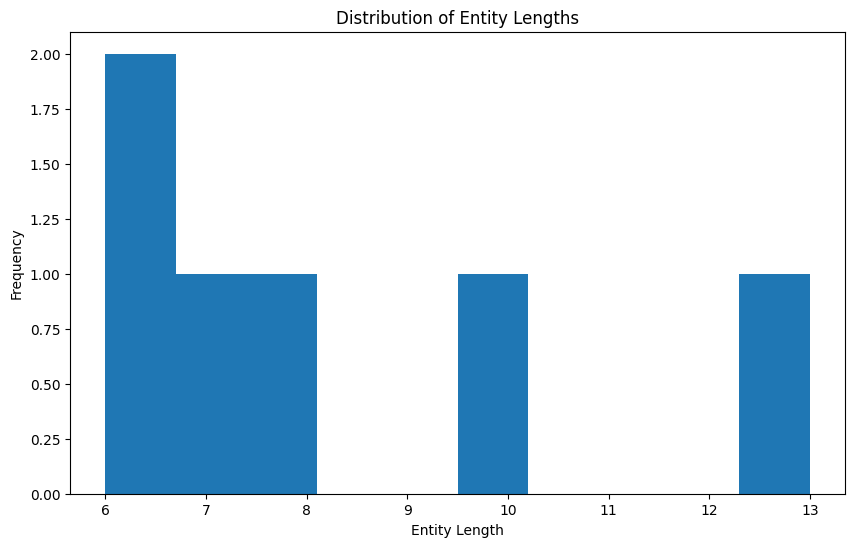

In [ ]:
entity_lengths = [len(ent.text) for ent in doc.ents]

plt.figure(figsize=(10, 6))
plt.hist(entity_lengths, bins=10)
plt.xlabel("Entity Length")
plt.ylabel("Frequency")
plt.title("Distribution of Entity Lengths")
plt.show()

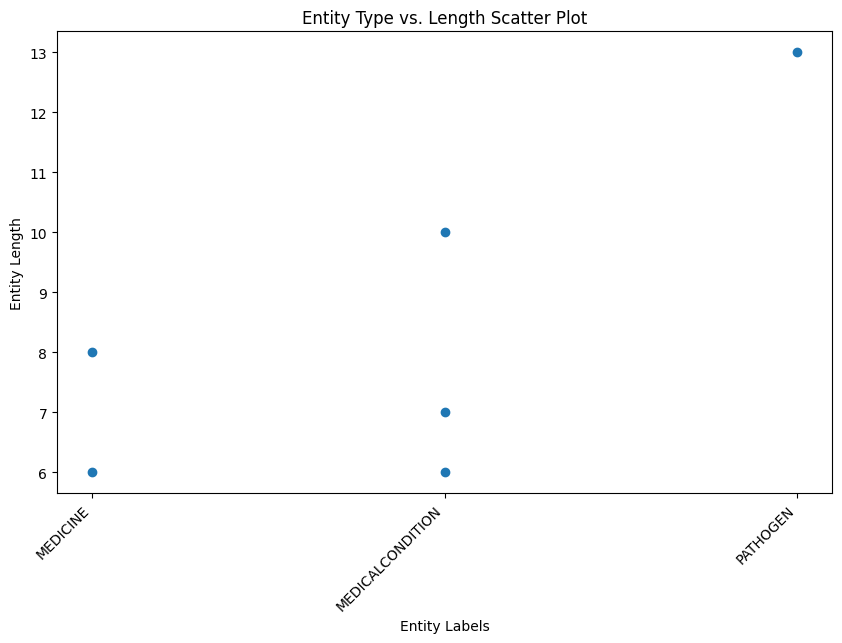

In [ ]:
# Entity Type vs. Length Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(entity_labels, entity_lengths)
plt.xlabel("Entity Labels")
plt.ylabel("Entity Length")
plt.title("Entity Type vs. Length Scatter Plot")
plt.xticks(rotation=45, ha='right')
plt.show()